In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("data/hearing_test.csv")

In [4]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [6]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [7]:
df["test_result"].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

<Axes: xlabel='test_result', ylabel='count'>

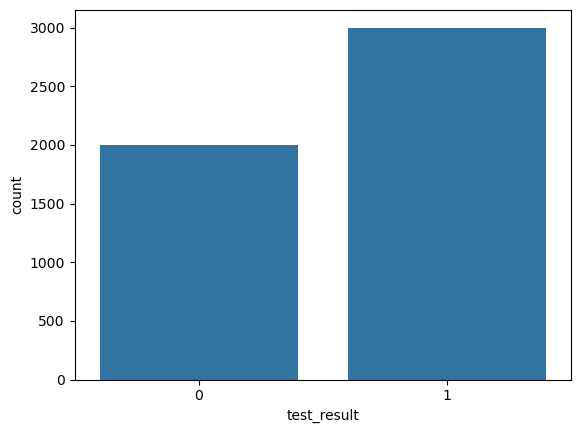

In [8]:
sns.countplot(data=df,x="test_result")

<Axes: xlabel='test_result', ylabel='age'>

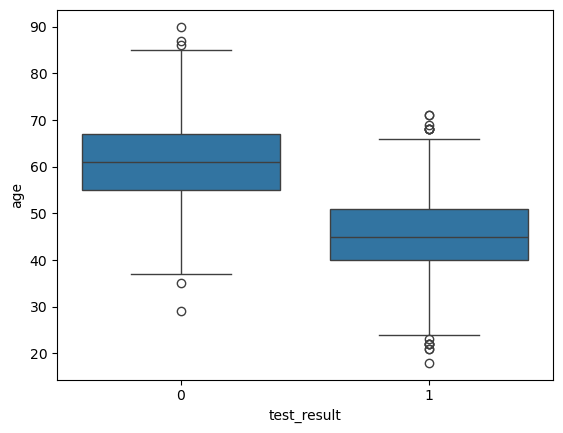

In [9]:
sns.boxplot(data=df,x="test_result",y="age")

<Axes: xlabel='age', ylabel='physical_score'>

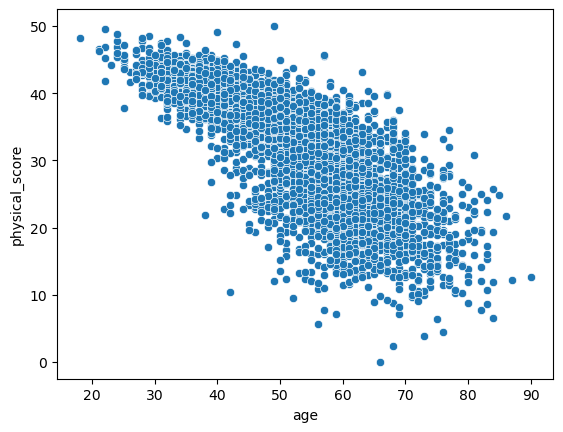

In [10]:
sns.scatterplot(x="age",y="physical_score",data=df)

In [11]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [12]:
X=df.drop("test_result",axis=1)
y=df["test_result"]

In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
scaled_X_train=scaler.transform(X_train)
scaled_X_test=scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()

In [16]:
log_model.fit(scaled_X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
log_model.coef_

array([[-0.9701145 ,  3.57047868]])

In [18]:
y_pred=log_model.predict(X_test)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [19]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [20]:
y_pred=log_model.predict(scaled_X_test)

In [21]:
y_pred

array([1, 0, 1, ..., 1, 1, 1], shape=(1500,))

In [22]:
accuracy_score(y_test,y_pred)

0.9053333333333333

In [23]:
cm=confusion_matrix(y_test,y_pred,labels=[1,0])
cm

array([[833,  58],
       [ 84, 525]])

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay


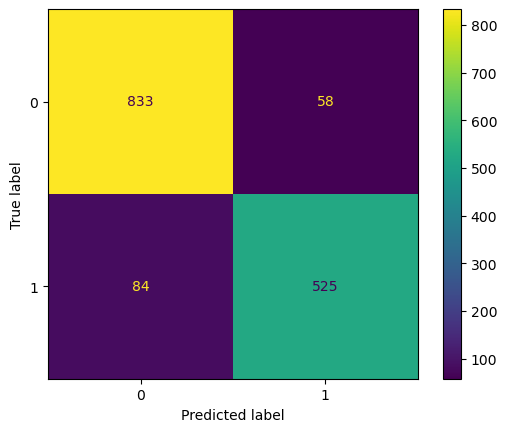

In [25]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88       609
           1       0.91      0.93      0.92       891

    accuracy                           0.91      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.91      0.91      0.90      1500



In [27]:
from sklearn.metrics import precision_score,recall_score

In [38]:
pr=precision_score(y_test,y_pred)
pr

0.9083969465648855

In [39]:
rc=recall_score(y_test,y_pred)
rc

0.9349046015712682

In [32]:
from sklearn.metrics import PrecisionRecallDisplay,RocCurveDisplay

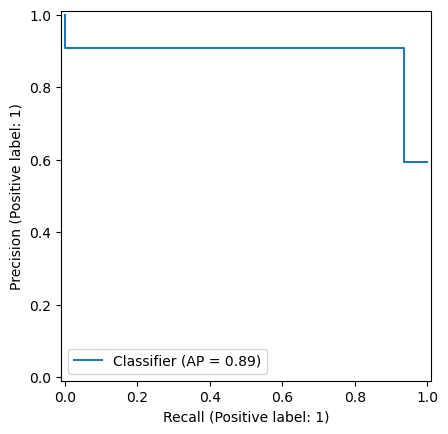

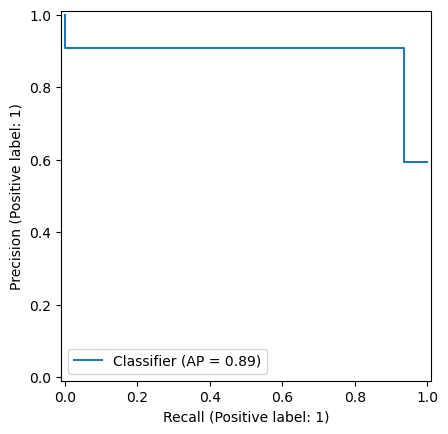

In [43]:
pr_rc_curve=PrecisionRecallDisplay.from_predictions(y_test,y_pred)
pr_rc_curve.plot()